
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Analyse multivariée
</p>

---



L'analyse multivariée a pour but d'étudier le lien entre plusieurs variables.

Sous-sections :
[Deux variables catégorielles](#cat_cat)&nbsp;|
[Une variable numérique et une variable catégorielle](#num_cat)&nbsp;|
[Deux variables numériques](#num_cat)&nbsp;|
[Modèles de prédiction interprétables](#pred)&nbsp;

Nous illustrerons les différentes notions à l'aide des jeux de données Iris, Zoo et Tips :

In [181]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [182]:
import pandas as pd
col_names = ['id',"hair", "feathers", 'eggs', 'milk', 'airborne', 'aquatic', 'predator','toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tails', 'domestic', 'catsize','type']
zoo = pd.read_csv('../data/zoo.data',index_col=0,names=col_names)
zoo.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tails,domestic,catsize,type
id,,,,,,,,,,,,,,,,,
aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [183]:
tips = pd.read_csv("../data/tips.csv",header = 0, sep = ",")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<a id="cat_cat"></a>
### Lien entre deux variables catégorielles

Si l'on veut mesurer le lien entre __deux variables catégorielles__ (par exemple, `aquatic` et `type` dans Zoo), on fait un _test du Khi-2 d'indépendance_.

__Test du Khi-2__

Le test du Khi-2 peut être appliqué si 80% des classes ont un effectif théorique $\geq$ 5 et le reste des classes est non vide (critère de Cochran).

On commence par faire une table de contingence :

In [184]:
observed = pd.crosstab(zoo['aquatic'],zoo['type'], margins=True)
observed

type,1,2,3,4,5,6,7,All
aquatic,,,,,,,,
0,35,14,4,0,0,8,4,65
1,6,6,1,13,4,0,6,36
All,41,20,5,13,4,8,10,101


ou 

In [185]:
import numpy as np
observed = zoo.groupby(['aquatic', 'type']).size().unstack(fill_value=0)
observed['Total'] = np.sum(observed,axis=1)
total = np.sum(observed,axis=0)
observed = pd.concat((observed,pd.DataFrame(data=total).transpose().assign(aquatic='Total').set_index('aquatic')),axis=0)
observed

type,1,2,3,4,5,6,7,Total
aquatic,,,,,,,,
0,35,14,4,0,0,8,4,65
1,6,6,1,13,4,0,6,36
Total,41,20,5,13,4,8,10,101


Puis on fait le test du Khi-2 :

In [186]:
import scipy.stats as st
khi2 = st.chi2_contingency(observed)
khi2.statistic, khi2.pvalue, khi2.expected_freq

(np.float64(46.411784448613716),
 np.float64(2.400789038143869e-05),
 array([[ 26.38613861,  12.87128713,   3.21782178,   8.36633663,
           2.57425743,   5.14851485,   6.43564356,  65.        ],
        [ 14.61386139,   7.12871287,   1.78217822,   4.63366337,
           1.42574257,   2.85148515,   3.56435644,  36.        ],
        [ 41.        ,  20.        ,   5.        ,  13.        ,
           4.        ,   8.        ,  10.        , 101.        ]]))

ce qui permet de reconstituer les effectifs théoriques à partir des valeurs marginales (colonnes "Total") :

In [187]:
theoriques = pd.DataFrame(data=khi2.expected_freq,index=observed.index,columns=observed.columns)
theoriques

type,1,2,3,4,5,6,7,Total
aquatic,,,,,,,,
0,26.386139,12.871287,3.217822,8.366337,2.574257,5.148515,6.435644,65.0
1,14.613861,7.128713,1.782178,4.633663,1.425743,2.851485,3.564356,36.0
Total,41.000000,20.000000,5.000000,13.000000,4.000000,8.000000,10.000000,101.0


On a `pvalue` $< .05$ donc on rejette l'hypothèse nulle (indépendance), donc on peut conclure qu'il y a un lien de dépendance entre `aquatic` et `type`.

<a id="num_cat"></a>
### Lien entre une variable numérique et une variable catégorielle


Si l'on veut mesurer le lien entre __un attribut numérique et un attribut catégoriel__ (par exemple, `sepal_width` et `species` dans Iris), on fait :
- un test _T de Student_ (2 classes) ou une _ANOVA_ (3+ classes) si l'attribut a une distribution normale
- un test de _Wilcoxon-Mann-Whitney_ (2 classes) ou un test de _Kruskal-Wallis_ (3+ classes) si l'attribut n'a pas une distribution normale

Un autre moyen d'appréhender la dépendance entre un attribut et une classe consiste à tracer une *courbe ROC*.

__Test de normalité__

Voici les répartitions des valeurs de l'attribut `sepal_width` selon la classe, affichés avec moyenne et écart type :

<Axes: xlabel='sepal_width', ylabel='species'>

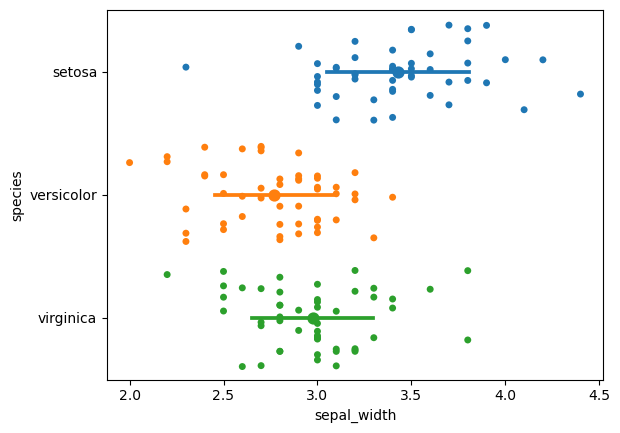

In [188]:
import seaborn as sns
sns.stripplot(iris,x='sepal_width', y='species',hue='species', jitter=.4)
sns.pointplot(iris,x='sepal_width', y='species', errorbar='sd', hue='species')

Pour vérifier que la distribution des classes est bien normale, on fait un test de Shapiro :

In [189]:
import scipy
setosa = iris.loc[iris['species'] == 'setosa']['sepal_length']
virginica = iris.loc[iris['species'] == 'virginica']['sepal_length']
versicolor = iris.loc[iris['species'] == 'versicolor']['sepal_length']
shapiro_test_setosa = scipy.stats.shapiro(setosa)
shapiro_test_virginica = scipy.stats.shapiro(virginica)
shapiro_test_versicolor = scipy.stats.shapiro(versicolor)
shapiro_test_setosa, shapiro_test_virginica, shapiro_test_versicolor

(ShapiroResult(statistic=np.float64(0.977698549796646), pvalue=np.float64(0.4595131499174534)),
 ShapiroResult(statistic=np.float64(0.971179397111026), pvalue=np.float64(0.25831474614079086)),
 ShapiroResult(statistic=np.float64(0.9778356785897521), pvalue=np.float64(0.4647370359250263)))

La `pvalue` donne la probabilité (sous l'hypothèse nulle de normalité) qu'on observe une valeur inférieure à la valeur calculée de `statistic`.

Ici elle est élevée, donc on ne rejette pas l'hypothèse de normalité.

Une autre méthode (visuelle celle-ci, donc plus subjective) consiste à faire un Q-Q plot pour comparer les quantiles de la variable avec ceux qu'on obtiendrait si la distribution était normale :

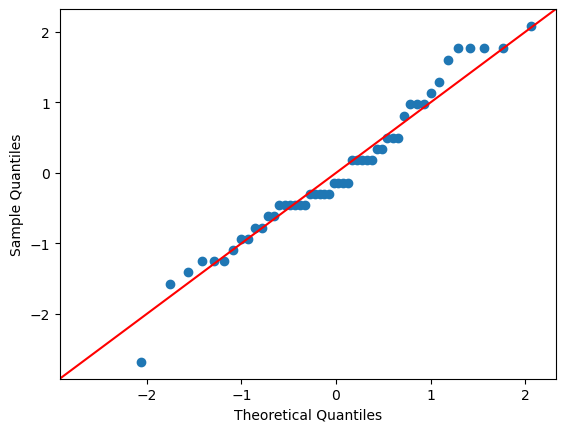

In [190]:
import statsmodels.api as sm
fig = sm.qqplot(virginica, fit=True, line='45')

On regarde alors si on s'écarte ou non de la diagonale.

__ANOVA (3 classes)__

La variable `sepal_length` a une distribution normale, donc on fait une ANOVA pour savoir si la différence de moyenne sur les 3 classes est statistiquement significative :

In [191]:
import scipy
scipy.stats.f_oneway(setosa,virginica,versicolor)

F_onewayResult(statistic=np.float64(119.26450218450468), pvalue=np.float64(1.6696691907693826e-31))

On obtient une `pvalue` << 5%, donc il y a un lien entre la variable `sepal_length` et la classe.

__Test de Student (2 classes)__

Dans Tips, on veut savoir s'il y a un lien entre la variable `total_bill` et le sexe (variable `sex`).

<Axes: xlabel='total_bill', ylabel='sex'>

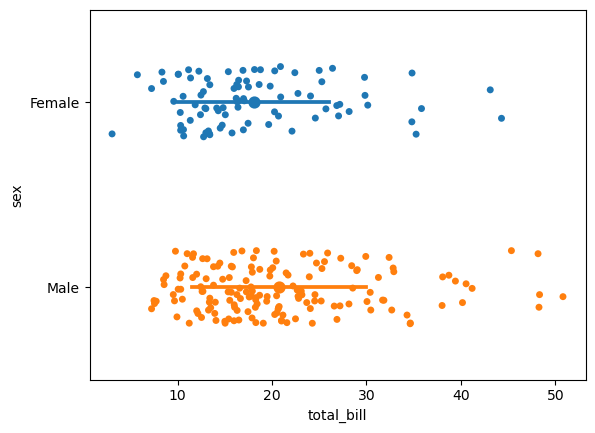

In [192]:
import seaborn as sns
sns.stripplot(tips,x='total_bill', y='sex',hue='sex', jitter=.2)
sns.pointplot(tips,x='total_bill', y='sex', errorbar='sd', hue='sex')

<Axes: xlabel='total_bill', ylabel='Count'>

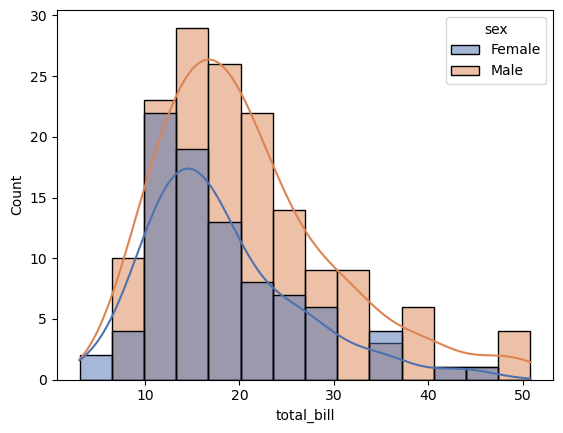

In [193]:
sns.histplot(tips,x='total_bill',hue='sex',kde=True, palette='deep')

On veut savoir si la différence de moyenne est statistiquement significative.

Pour pouvoir appliquer le test de Student, il faut vérifier que la variable suit une distribution normale.

On fait un test de Shapiro :

In [194]:
import scipy
male = tips.loc[tips['sex'] == 'Male']['total_bill']
female = tips.loc[tips['sex'] == 'Female']['total_bill']
shapiro_test_male = scipy.stats.shapiro(male)
shapiro_test_female = scipy.stats.shapiro(female)
shapiro_test_male, shapiro_test_female

(ShapiroResult(statistic=np.float64(0.9187337722958244), pvalue=np.float64(1.0274536685915797e-07)),
 ShapiroResult(statistic=np.float64(0.9188766163908312), pvalue=np.float64(4.211812241575292e-05)))

La `pvalue` donne la probabilité (sous l'hypothèse nulle de normalité) qu'on observe une valeur inférieure à la valeur calculée de `statistic`.

Ici elle est très faible, donc on rejette l'hypothèse de normalité.

Néanmoins, on remarque que si l'on prend le logarithme des valeurs de `total_bill`, on obtient une nouvelle variable qui elle suit une loi normale :

In [195]:
import scipy
import numpy as np
male = np.log(tips.loc[tips['sex'] == 'Male']['total_bill'])
female = np.log(tips.loc[tips['sex'] == 'Female']['total_bill'])
shapiro_test_male = scipy.stats.shapiro(male)
shapiro_test_female = scipy.stats.shapiro(female)
shapiro_test_male, shapiro_test_female

(ShapiroResult(statistic=np.float64(0.9925489624804876), pvalue=np.float64(0.5930718732610409)),
 ShapiroResult(statistic=np.float64(0.9734256673702187), pvalue=np.float64(0.07007784009940422)))

La `pvalue` donne la probabilité (sous l'hypothèse nulle de normalité) qu'on observe une valeur inférieure à la valeur calculée de `statistic`.

Ici elle est élevée, donc on ne rejette pas l'hypothèse de normalité.

On peut faire un test de Student sur les logarithmes des valeurs :

In [196]:
import scipy
scipy.stats.ttest_ind(male,female,equal_var=False)

TtestResult(statistic=np.float64(2.393945823575832), pvalue=np.float64(0.01774056034844257), df=np.float64(172.5455727914267))

On obtient une `pvalue` < 5%, donc il y a un lien statistiquement significatif entre la variable `total_bill` et la variable `sex`.

__Test de Wilcoxon (2 classes)__

On s'intéresse à la tâche de prédire si une fleur est de classe versicolor ou non (classification binaire).

Voici la moyenne et l'écart type sur la classe versicolor *vs* sur les autres classes :

<Axes: xlabel='sepal_length', ylabel='classe'>

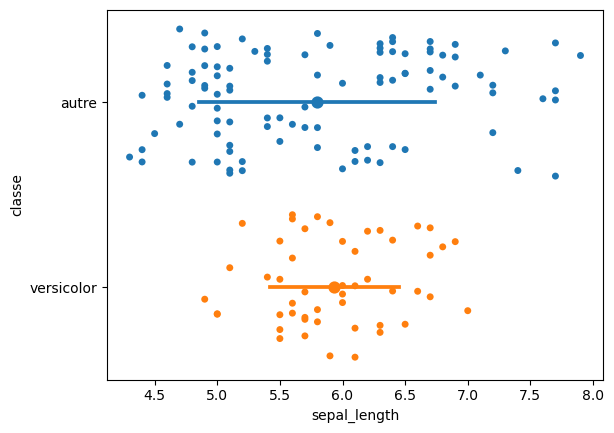

In [197]:
import pandas as pd
df = iris.copy()
conditions = [(df['species'] == 'versicolor'), (df['species'] != 'versicolor') ]
values = (1.,0.)
df['classe'] = pd.Series(np.select(conditions, values)).map({1.:'versicolor', 0.:'autre'})
sns.stripplot(df,x='sepal_length', y='classe',hue='classe', jitter=.4)
sns.pointplot(df,x='sepal_length', y='classe', errorbar='sd', hue='classe')

<Axes: xlabel='sepal_length', ylabel='Count'>

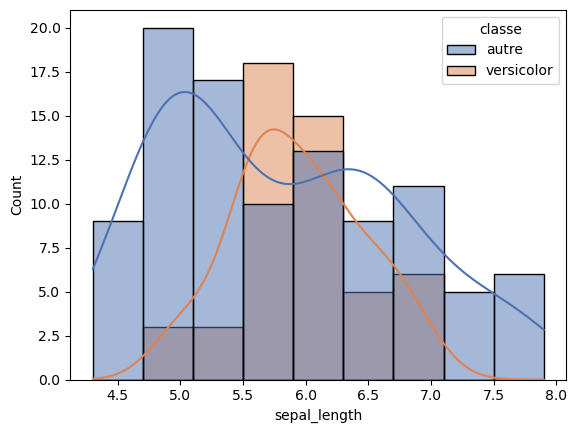

In [198]:
sns.histplot(df,x='sepal_length',hue='classe',kde=True, palette='deep')

On se demande si la différence de moyenne entre les deux classes est statistiquement significative.



__Test de normalité__

Pour vérifier que la distribution des classes est bien normale, on fait un test de Shapiro :

In [199]:
import scipy
versicolor = df.loc[df['classe'] == 'versicolor']['sepal_length']
autre = df.loc[df['classe'] == 'autre']['sepal_length']
shapiro_test_versicolor = scipy.stats.shapiro(versicolor)
shapiro_test_autre = scipy.stats.shapiro(autre)
shapiro_test_versicolor, shapiro_test_autre

(ShapiroResult(statistic=np.float64(0.9778356785897521), pvalue=np.float64(0.4647370359250263)),
 ShapiroResult(statistic=np.float64(0.9455555004141006), pvalue=np.float64(0.00042770118095666784)))

La `pvalue` donne la probabilité (sous l'hypothèse nulle de normalité) qu'on observe une valeur inférieure à la valeur calculée de `statistic`.

Ici elle est élevée, donc on rejette l'hypothèse de normalité.

Comme il y a seulement 2 classes et que la distribution des classes n'est pas normale, 
on fait un test de Wilcoxon-Mann-Whitney :

In [200]:
scipy.stats.mannwhitneyu(versicolor, autre)

MannwhitneyuResult(statistic=np.float64(2857.5), pvalue=np.float64(0.15428414495666523))

On obtient une valeur supérieure à 5%, (`pvalue` $> .05$) donc il n'y a pas de dépendance statistiquement significative entre la variable `sepal_length` et la classe `versicolor`.

__Courbe ROC__

Une courbe ROC permet de visualiser les taux de Vrais Positifs (TPR) et de Faux Positifs (FPR) lorsqu'on fait varier un seuil :

![roc_seuil](../images/rudin_roc1.png)

(d'après https://users.cs.duke.edu/~cynthia/CourseNotes/ROCII.pdf)


L'AUC (*Area Under Curve*) mesure la qualité d'un prédicteur $f$ en donnant la probabilité que l'ordre engendré sur ses valeurs lorsqu'on fait varier le seuil reflète l'ordre des classes :
<p align='center'>
AUC = Probabilité (une paire + / - est correctement ordonnée par le prédicteur)
<p>

![roc_curve](../images/rudin_roc2.png)

Le prédicteur $f$ est d'autant meilleur que la courbe ROC __s'écarte de la diagonale__ (AUC élevé).

Ici on prend juste comme prédicteur $f$ la variable `sepal_width` :

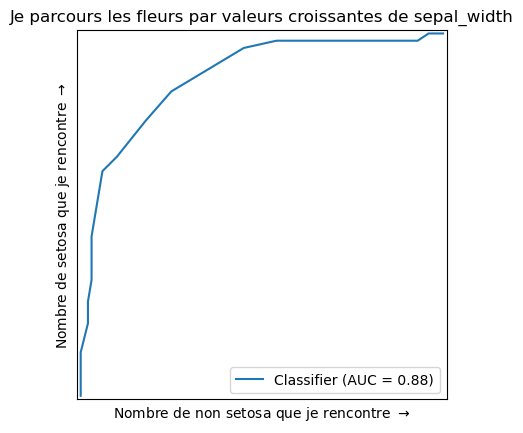

In [201]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
y_true = iris['species'].values == 'setosa'
y_score = iris['sepal_width'].values
RocCurveDisplay.from_predictions(y_true, y_score)
ax = plt.gca()
ax.set_xlabel(r'Nombre de non setosa que je rencontre $\rightarrow$')
ax.set_ylabel(r'Nombre de setosa que je rencontre $\rightarrow$')
ax.set_title('Je parcours les fleurs par valeurs croissantes de sepal_width')
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)


Regarder à quel point on s'écarte de la diagonale permet d'avoir une première indication sur l'influence de cette variable sur la variable de classe :

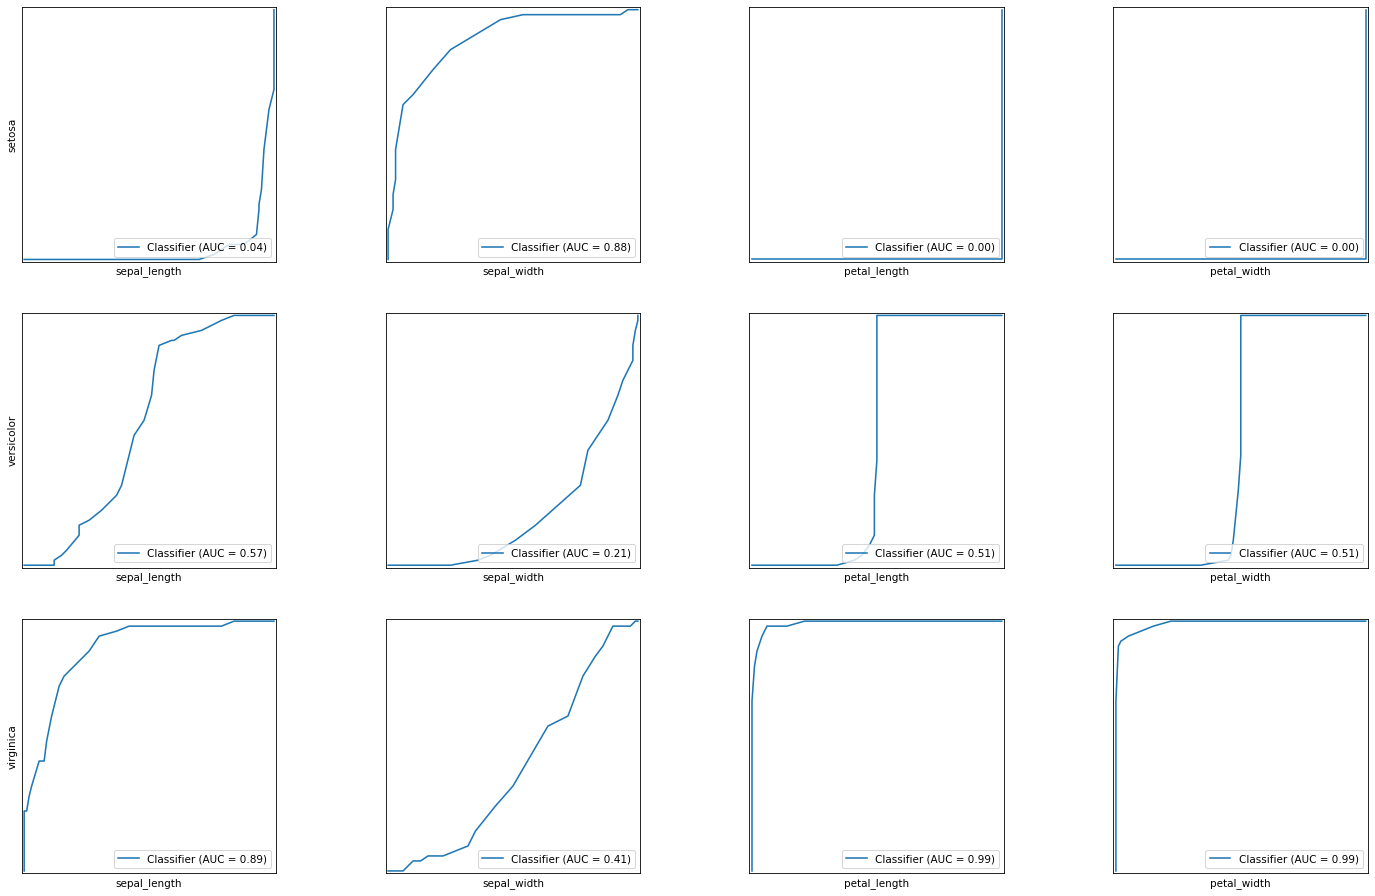

In [202]:
import matplotlib.pyplot as plt

features = iris.columns[:-1]
classes = iris['species'].unique()

fig, axs = plt.subplots(ncols=len(features),nrows=len(classes),figsize=(6*len(features),5*len(classes)), dpi=75)

for i in range(len(classes)):
    cls = classes[i]
    for j in range(len(features)):
        feature = features[j]
        y_true = iris['species'].values == cls
        RocCurveDisplay.from_predictions(y_true, iris[feature], ax=axs[i,j])
        axs[i,j].set_xlabel(feature)
        axs[i,j].set_ylabel("" if j > 0 else cls)
        axs[i,j].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        axs[i,j].tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

<a id="num_num"></a>
### Lien entre deux variables numériques

__Test de corrélation de Pearson__

Pour déterminer s'il y a une dépendance (linéaire) entre deux variables numériques, on peut calculer le coefficient de corrélation :

In [203]:
corr = iris.iloc[:,:-1].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


et visualiser la matrice de corrélation :

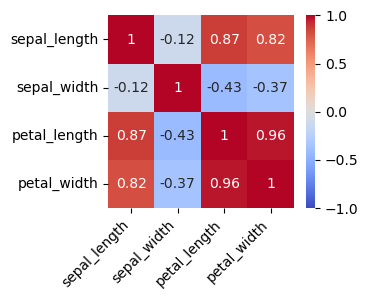

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
def correlation_heatmap(matrix):
    fig, ax = plt.subplots(figsize=(3, 2.5))

    sns.heatmap(matrix, cmap='coolwarm', annot=True, vmin=-1, vmax=1)

    tick_marks = [i + .5 for i in range(len(matrix.columns))]
    plt.xticks(tick_marks, matrix.columns, rotation=45, ha='right')
    plt.yticks(tick_marks, matrix.index, rotation='horizontal')

correlation_heatmap(corr)

ou, si on enlève la diagonale et la symétrie :

In [205]:
masked_corr = corr.copy()
mask = np.zeros_like(masked_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
masked_corr[mask] = np.nan
masked_corr = masked_corr.iloc[1:,:-1]
masked_corr

,sepal_length,sepal_width,petal_length
sepal_width,-0.117570,NaN,NaN
petal_length,0.871754,-0.428440,NaN
petal_width,0.817941,-0.366126,0.962865


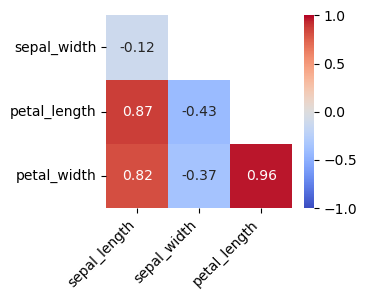

In [206]:
correlation_heatmap(masked_corr)

Une valeur proche de 1 (resp., -1) traduit une dépendance positive (resp., négative) entre les deux variables :

![correlation wikipedia](../images/correlation_wikipedia.png)
(d'après wikipedia)

Pour savoir si ces mesures sont statistiquement significatives sur le jeu de données, on fait un *test de corrélation de Pearson* :

In [207]:
import scipy
scipy.stats.pearsonr(corr['petal_length'],y=corr['petal_width']).pvalue

np.float64(0.0019706129371361847)

In [208]:
p_corr = masked_corr.copy()
for (row,col) in zip(p_corr.index,p_corr.columns):
    p_corr.loc[row,col]= scipy.stats.pearsonr(corr[row],y=corr[col]).pvalue
p_corr

,sepal_length,sepal_width,petal_length
sepal_width,0.058094,NaN,NaN
petal_length,0.871754,0.007849,NaN
petal_width,0.817941,-0.366126,0.001971


In [209]:
masked_corr[p_corr < .05]

,sepal_length,sepal_width,petal_length
sepal_width,NaN,NaN,NaN
petal_length,NaN,-0.428440,NaN
petal_width,NaN,-0.366126,0.962865


On affiche les associations statistiquement significatives (p < 5%):

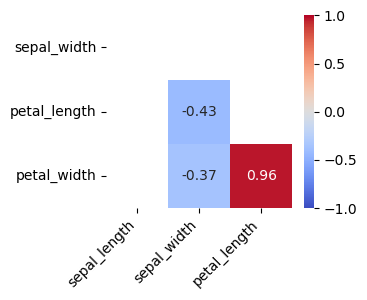

In [210]:
correlation_heatmap(masked_corr[p_corr < .05])

<a id="selection"></a>
### Sélection de variables (et réduction de dimension)

__L'analyse en composantes principales (ACP)__

Il existe de nombreuses manières pour réduire la dimension des données.

L'une d'elles, l'*analyse en composante principales*, projete les données dans un espace de dimension inférieure (en diagonalisant la matrice des corrélations) de manière à maximiser la variance.

L'ACP ne tient pas compte des classes, contrairement à l'*analyse discriminante linéaire (ADL)*.

In [211]:
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler
features, cls = iris.columns[:-1], iris.columns[-1]
X, y = iris.loc[:,features].values, iris.loc[:,cls].values
sc = StandardScaler()
X = sc.fit_transform(X)
pca = decomposition.PCA(n_components=4)
pca.fit(X)

,n_components,4
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


Chaque dimension obtenue est une combinaison linéaire des dimensions initiales.

Par exemple, voici les coefficients de la première dimension :

In [212]:
pc1 = pd.Series(data = pca.components_[0],index=features)
coefs = pc1.sort_values(key=lambda x:np.abs(x),ascending=False)
coefs

petal_length    0.580413
petal_width     0.564857
sepal_length    0.521066
sepal_width    -0.269347
dtype: float64

On peut se servir de ces coefficients pour avoir une indication de quels attributs jouent le plus grand rôle dans la variance des données.

Pour savoir combien de dimensions conserver, on peut faire un scree plot :

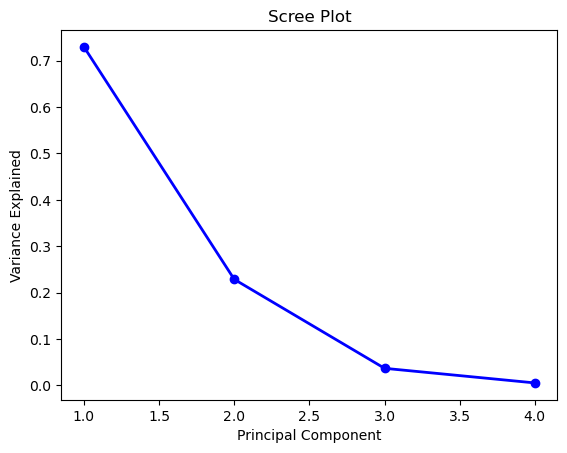

In [213]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

Le nombre de composants retenus est le point de plus grande courbure (ici d=3).

__Sélection de variables__

Les méthodes de sélection de variable sont nombreuses (cf projet).
Elles ont pour but de ne garder que les variables les plus importantes dans une tâche de prédiction.

La méthode __kbest__ consiste à ne garder que les $k$ variables qui maximisent un score donné, comme par exemple la probabilité ($1 - p$) que la classe dépende de cette variable.

In [214]:
import scipy.stats as st
pvalues = {}
for a in zoo.columns[:-1]:
    observed = pd.crosstab(zoo[a],zoo['type'], margins=True)
    khi2 = st.chi2_contingency(observed)
    pvalues[a] = khi2.pvalue

k = 7
pd.Series(pvalues,name='pvalues').sort_values()[:k]

legs        7.027547e-30
feathers    3.049466e-15
backbone    3.049466e-15
milk        3.049466e-15
toothed     7.974466e-14
eggs        3.819070e-13
hair        3.255310e-12
Name: pvalues, dtype: float64

<a id="pred"></a>
### Modèles de prédiction interprétables

Une autre façon d'explorer l'importance des différentes variables d'un jeu de données consiste à apprendre un modèle des données, puis à observer quels sont les paramètres de ce modèle.

__Régression linéaire__

Lorsque la tâche consiste à prédire une valeur numérique (régression),
le modèle des données le plus simple qu'on peut chercher à apprendre est une droite :

$Z$ = $x_0$ + $x_1$.$X_1$ + $x_2$.$X_2$ ... + $x_j$.$X_j$

In [215]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [222]:
from sklearn import linear_model
features, tgt_att = ['size','tip'], 'total_bill'
X, y = tips.loc[:,features].values, tips[tgt_att].values
reg = linear_model.LinearRegression()
reg.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Voici les coefficients appris par le modèle :

$Z$ = $x_0$ + $x_1$.`size` + $x_2$.`tip`

avec

In [223]:
pd.Series(data=[reg.intercept_]+list(reg.coef_),index=['x0','x1','x2'])

x0    1.607298
x1    3.294182
x2    3.239751
dtype: float64

Text(0.5, 0, 'total_bill')

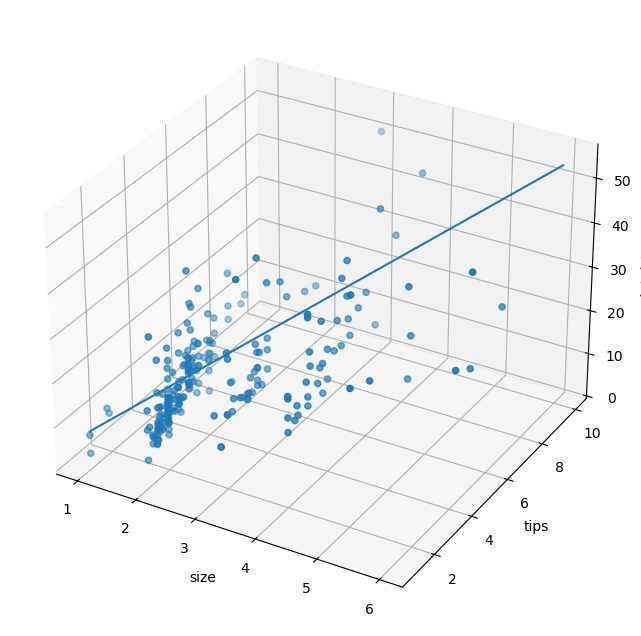

In [224]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 8))
axes = plt.axes(projection="3d")
sizes = X[:,0]
given_tips = X[:,1]
total_bill = y
axes.scatter3D(sizes, given_tips, total_bill)
x_sizes = np.linspace(np.min(sizes),np.max(sizes))
x_tips = np.linspace(np.min(given_tips),np.max(given_tips))
predictions = reg.predict(np.concat((x_sizes[:,None],x_tips[:,None]),axis=1))
axes.plot3D(x_sizes, x_tips, predictions)
axes.set_xlabel("size")
axes.set_ylabel("tips")
axes.set_zlabel("total_bill")

Text(0, 0.5, 'total_bill')

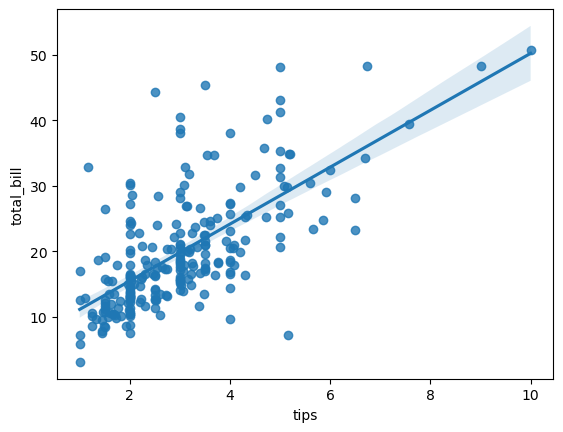

In [233]:
sns.regplot(x=given_tips,y=total_bill)
plt.xlabel('tips')
plt.ylabel('total_bill')

La qualité de la droite apprise peut être mesurée par la quantité de variance expliquée (__R² score__) par le modèle :

In [219]:
reg.score(X,y)

0.5508230520073981

Ici $55$ % de la variabilité de `total_bill` peut être expliquée par cette droite, donc d'autres variables doivent entrer en jeu qui ne sont pas considérées ici.

Pour savoir si la liaison est statistiquement significative pour chacune des variables, on peut regarder les __pvalues__ de chaque variable :

In [220]:
import statsmodels.api as sm
reg = sm.OLS(y,sm.add_constant(X)).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     147.8
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.31e-42
Time:                        17:22:21   Log-Likelihood:                -781.54
No. Observations:                 244   AIC:                             1569.
Df Residuals:                     241   BIC:                             1580.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6073      1.168      1.376      0.170      -0.693       3.908
x1             3.2942      0.463      7.110      0.000       2.381       4.207
x2             3.2398      0.319     10.172      0.000       2.612       3.867
==============================================================================
Omnibus:                       64.747   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              147.953
Skew:                           1.249   Prob(JB):                     7.45e-33
Kurtosis:                       5.882   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [221]:
print("x0, x1, x2: ", reg.params)
print("R2: ", reg.rsquared)
print('pvalues de x0, x1, x2: ', reg.pvalues)

x0, x1, x2:  [1.60729811 3.29418196 3.23975119]
R2:  0.5508230520073981
pvalues de x0, x1, x2:  [1.70031934e-01 1.31473114e-11 1.88091701e-20]


Les pvalues de `size` et `tip` sont << 5% donc statistiquement significatives.

__Régression logistique__

On peut adapter ce modèle linéaire dans le cas d'une tâche de classification binaire.

Dans ce cas, au lieu de prédire une classe,
on cherche à prédire la différence de contenu informationnel entre les classes $0$ et $1$ 

$ln(\frac{p(1|X)}{p(0|X)}) = ln(p(1|X)) - ln(p(0|X))$

On fait l'hypothèse que cette grandeur peut être approximée par une droite :

$ln(\frac{p(1|X)}{p(0|X)})$ = $x_0$ + $x_1$.$X_1$ + $x_2$.$X_2$ ... + $x_j$.$X_j$

et on cherche les coefficients $x_i$ de cette droite.

In [ ]:
from sklearn.linear_model import LogisticRegression
features, tgt_att = ['size','tip'], 'smoker'
X, y = tips.loc[:,features].values, tips[tgt_att].values
clf = LogisticRegression(random_state=0).fit(X, y)

Voici les coefficients appris par le modèle :

$Z$ = $x_0$ + $x_1$.`size` + $x_2$.`tip`

avec

In [275]:
pd.Series(data=np.concat((clf.intercept_,clf.coef_.squeeze()),axis=0),index=['x0','x1','x2'])

x0    0.130314
x1   -0.407768
x2    0.139130
dtype: float64

In [243]:
clf.predict_proba(X)

array([[0.63290517, 0.36709483],
       [0.70308533, 0.29691467],
       [0.64703552, 0.35296448],
       [0.55594003, 0.44405997],
       [0.730763  , 0.269237  ],
       [0.69961262, 0.30038738],
       [0.60035907, 0.39964093],
       [0.74396332, 0.25603668],
       [0.60169357, 0.39830643],
       [0.55868606, 0.44131394],
       [0.60999929, 0.39000071],
       [0.69106567, 0.30893433],
       [0.61462311, 0.38537689],
       [0.74713056, 0.25286944],
       [0.56587693, 0.43412307],
       [0.53490098, 0.46509902],
       [0.7027948 , 0.2972052 ],
       [0.64033454, 0.35966546],
       [0.64703552, 0.35296448],
       [0.65178697, 0.34821303],
       [0.52935881, 0.47064119],
       [0.57508134, 0.42491866],
       [0.5926573 , 0.4073427 ],
       [0.60972348, 0.39027652],
       [0.56040053, 0.43959947],
       [0.76408232, 0.23591768],
       [0.60035907, 0.39964093],
       [0.60035907, 0.39964093],
       [0.52172677, 0.47827323],
       [0.56656038, 0.43343962],
       [0.